
# YOLO + Super-Resolution Detection Evaluation with Ground Truth Labels

Acest notebook compară dacă variantele de Super-Resolution ajută detecția YOLO folosind **label-uri reale COCO**.

Pipeline:
1. citește imagini COCO + `instances_val2017.json`
2. generează variante:
   - HR
   - Bicubic x4
   - SRCNN_x4_V4
   - SRCNN_x4_Adaptive
   - variantele 3Region
3. rulează YOLO pe fiecare variantă
4. compară predicțiile cu ground truth prin IoU
5. calculează:
   - Precision
   - Recall
   - F1
   - AP@0.5
   - mAP@0.5 pe clasele prezente



## 0. Instalare librării

În env-ul tău:

```bash
python -m pip install ultralytics opencv-python tqdm
```

Pentru COCO labels, acest notebook citește JSON-ul direct, deci nu are nevoie obligatoriu de `pycocotools`.


In [1]:

# IMPORTANT pentru Windows / VS Code când apare eroare libiomp5md.dll
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import json
import math
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from ultralytics import YOLO

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


torch: 2.11.0+cpu
cuda available: False



## 1. Config

Structura recomandată:

```text
Implementare/
├── srcnn_x4.pth
├── srcnn_x4_adaptive.pth
├── srcnn_x4_adaptive_3region_base.pth
├── ...
├── data/
│   └── coco/
│       ├── val2017/
│       │   ├── 000000000139.jpg
│       │   └── ...
│       └── annotations/
│           └── instances_val2017.json
```

Poți pune doar un subset de imagini în `val2017`, dar JSON-ul trebuie să fie cel original COCO.


In [2]:

# -------------------------
# Paths
# -------------------------
COCO_IMG_DIR = Path("data/test_detection/")
COCO_ANN_JSON = Path("data/test_detection/instances_val2017.json")

OUTPUT_DIR = Path("results_yolo_gt_compare")
OUTPUT_IMAGES_DIR = OUTPUT_DIR / "generated_images"
OUTPUT_DET_DIR = OUTPUT_DIR / "detections_visual"
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_IMAGES_DIR.mkdir(exist_ok=True)
OUTPUT_DET_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEFAULT_SCALE = 4

# YOLO model pretrained COCO
YOLO_MODEL_NAME = "yolov8n.pt"
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50

# Câte imagini COCO să folosești.
# Pune None pentru toate imaginile disponibile în COCO_IMG_DIR.
MAX_IMAGES = 100

# "all", "small", "medium", "large"
FILTER_OBJECT_SIZE = "all"

# Checkpoint-urile tale. Dacă unul nu există, este sărit automat.
CHECKPOINTS = {
    "SRCNN_x4_V4": "./srcnn_v4/srcnn_x4.pth",
    "SRCNN_x4_Adaptive": "./srcnn_adaptive/srcnn_x4_adaptive.pth",
    "3Region_Base": "./srcnn_adaptive_3region/srcnn_x4_adaptive_3region.pth",
    "3Region_Edge12": "./srcnn_adaptive_3region/srcnn_x4_adaptive_3region_ponderi.pth",
    "3Region_Thr1035": "./srcnn_adaptive_3region/srcnn_x4_adaptive_3region_thr1035.pth",
    "3Region_Thr2055_Edge12": "./srcnn_adaptive_3region/srcnn_x4_adaptive_3region_thr2055_edge12.pth",
}

print("Device:", DEVICE)
print("COCO images:", COCO_IMG_DIR.resolve())
print("COCO annotations:", COCO_ANN_JSON.resolve())
print("Output:", OUTPUT_DIR.resolve())


Device: cpu
COCO images: C:\Users\cezica\Desktop\Master\Disertatie\Implementare\data\test_detection
COCO annotations: C:\Users\cezica\Desktop\Master\Disertatie\Implementare\data\test_detection\instances_val2017.json
Output: C:\Users\cezica\Desktop\Master\Disertatie\Implementare\results_yolo_gt_compare


In [3]:

# -------------------------
# SRCNN model
# -------------------------
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 128, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(128, 64, kernel_size=1, padding=0)
        self.conv3 = nn.Conv2d(64, 1, kernel_size=5, padding=2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)
        return x

def load_srcnn_checkpoint(path: Path):
    ckpt = torch.load(path, map_location=DEVICE)
    model = SRCNN().to(DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    scale = ckpt.get("scale", DEFAULT_SCALE)
    return model, scale, ckpt

def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    return transforms.ToTensor()(img)

def tensor_to_pil(img_t: torch.Tensor) -> Image.Image:
    img_t = img_t.detach().cpu().clamp(0, 1)
    return transforms.ToPILImage()(img_t)

@torch.no_grad()
def apply_srcnn(model: nn.Module, bicubic_img: Image.Image) -> Image.Image:
    bic_ycbcr = bicubic_img.convert("YCbCr")
    bic_y, bic_cb, bic_cr = bic_ycbcr.split()
    bic_y_t = pil_to_tensor(bic_y).unsqueeze(0).to(DEVICE)

    res = model(bic_y_t)
    sr_y_t = torch.clamp(bic_y_t + res, 0.0, 1.0)

    sr_y_pil = tensor_to_pil(sr_y_t.squeeze(0))
    sr_ycbcr = Image.merge("YCbCr", (sr_y_pil, bic_cb, bic_cr))
    return sr_ycbcr.convert("RGB")

def crop_to_scale(img: Image.Image, scale: int) -> Image.Image:
    w, h = img.size
    w2 = w - (w % scale)
    h2 = h - (h % scale)
    return img.crop((0, 0, w2, h2))

def make_bicubic_variant(hr_img: Image.Image, scale: int):
    hr_img = crop_to_scale(hr_img, scale)
    w, h = hr_img.size
    lr = hr_img.resize((w // scale, h // scale), Image.BICUBIC)
    bic = lr.resize((w, h), Image.BICUBIC)
    return hr_img, lr, bic


In [4]:

# -------------------------
# Load SR models
# -------------------------
models = {}
model_meta = {}

for name, ckpt_name in CHECKPOINTS.items():
    path = Path(ckpt_name)
    if not path.exists():
        print(f"SKIP {name}: nu există {path}")
        continue

    try:
        model, scale, ckpt = load_srcnn_checkpoint(path)
        models[name] = model
        model_meta[name] = {"scale": scale, "path": str(path), "ckpt": ckpt}
        print(f"Loaded {name}: {path} scale=x{scale}")
    except Exception as e:
        print(f"ERROR loading {name}: {path} -> {e}")

print("Loaded models:", list(models.keys()))


Loaded SRCNN_x4_V4: srcnn_v4\srcnn_x4.pth scale=x4
Loaded SRCNN_x4_Adaptive: srcnn_adaptive\srcnn_x4_adaptive.pth scale=x4
Loaded 3Region_Base: srcnn_adaptive_3region\srcnn_x4_adaptive_3region.pth scale=x4
Loaded 3Region_Edge12: srcnn_adaptive_3region\srcnn_x4_adaptive_3region_ponderi.pth scale=x4
Loaded 3Region_Thr1035: srcnn_adaptive_3region\srcnn_x4_adaptive_3region_thr1035.pth scale=x4
Loaded 3Region_Thr2055_Edge12: srcnn_adaptive_3region\srcnn_x4_adaptive_3region_thr2055_edge12.pth scale=x4
Loaded models: ['SRCNN_x4_V4', 'SRCNN_x4_Adaptive', '3Region_Base', '3Region_Edge12', '3Region_Thr1035', '3Region_Thr2055_Edge12']


In [5]:

# -------------------------
# Load COCO annotations
# -------------------------
assert COCO_ANN_JSON.exists(), f"Nu există {COCO_ANN_JSON}"
assert COCO_IMG_DIR.exists(), f"Nu există {COCO_IMG_DIR}"

with open(COCO_ANN_JSON, "r", encoding="utf-8") as f:
    coco = json.load(f)

images_info = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

cat_id_to_name = {c["id"]: c["name"] for c in categories}
cat_name_to_id = {c["name"]: c["id"] for c in categories}

file_to_img = {img["file_name"]: img for img in images_info}
id_to_img = {img["id"]: img for img in images_info}

anns_by_image = {}
for ann in annotations:
    if ann.get("iscrowd", 0) == 1:
        continue
    anns_by_image.setdefault(ann["image_id"], []).append(ann)

available_files = sorted([
    p.name for p in COCO_IMG_DIR.glob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"] and p.name in file_to_img
])

print("Available COCO images with annotations:", len(available_files))
print("Categories:", len(categories))


Available COCO images with annotations: 100
Categories: 80


In [6]:

def ann_area_group(ann) -> str:
    area = ann.get("area", ann["bbox"][2] * ann["bbox"][3])
    if area < 32**2:
        return "small"
    if area < 96**2:
        return "medium"
    return "large"

def image_matches_filter(file_name: str, size_filter: str) -> bool:
    if size_filter == "all":
        return True
    img_id = file_to_img[file_name]["id"]
    anns = anns_by_image.get(img_id, [])
    return any(ann_area_group(a) == size_filter for a in anns)

selected_files = [f for f in available_files if image_matches_filter(f, FILTER_OBJECT_SIZE)]

if MAX_IMAGES is not None:
    selected_files = selected_files[:MAX_IMAGES]

print("Selected images:", len(selected_files))
print(selected_files[:10])


Selected images: 100
['000000000139.jpg', '000000000285.jpg', '000000000632.jpg', '000000000724.jpg', '000000000776.jpg', '000000000785.jpg', '000000000802.jpg', '000000000872.jpg', '000000000885.jpg', '000000001000.jpg']


In [7]:

# -------------------------
# Bounding box utilities
# -------------------------
def coco_xywh_to_xyxy(box):
    x, y, w, h = box
    return [x, y, x + w, y + h]

def compute_iou(box1, box2) -> float:
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0.0, x2 - x1)
    inter_h = max(0.0, y2 - y1)
    inter = inter_w * inter_h

    area1 = max(0.0, box1[2] - box1[0]) * max(0.0, box1[3] - box1[1])
    area2 = max(0.0, box2[2] - box2[0]) * max(0.0, box2[3] - box2[1])
    union = area1 + area2 - inter

    if union <= 0:
        return 0.0
    return inter / union

def get_gt_for_image(file_name: str, crop_w: int, crop_h: int):
    img_info = file_to_img[file_name]
    img_id = img_info["id"]

    gts = []
    for ann in anns_by_image.get(img_id, []):
        x1, y1, x2, y2 = coco_xywh_to_xyxy(ann["bbox"])

        x1 = max(0, min(x1, crop_w))
        x2 = max(0, min(x2, crop_w))
        y1 = max(0, min(y1, crop_h))
        y2 = max(0, min(y2, crop_h))

        if x2 <= x1 or y2 <= y1:
            continue

        cat_id = ann["category_id"]
        gts.append({
            "image": file_name,
            "image_id": img_id,
            "category_id": cat_id,
            "class_name": cat_id_to_name[cat_id],
            "bbox": [float(x1), float(y1), float(x2), float(y2)],
            "area_group": ann_area_group(ann),
        })
    return gts


In [8]:

# -------------------------
# Generate image variants
# -------------------------
def save_variant_images(file_name: str):
    img_path = COCO_IMG_DIR / file_name
    hr = Image.open(img_path).convert("RGB")

    hr, lr, bic = make_bicubic_variant(hr, DEFAULT_SCALE)

    image_stem = Path(file_name).stem
    variant_paths = {}

    hr_path = OUTPUT_IMAGES_DIR / f"{image_stem}__HR.png"
    hr.save(hr_path)
    variant_paths["HR"] = hr_path

    bic_path = OUTPUT_IMAGES_DIR / f"{image_stem}__Bicubic.png"
    bic.save(bic_path)
    variant_paths["Bicubic"] = bic_path

    for model_name, model in models.items():
        sr = apply_srcnn(model, bic)
        out_path = OUTPUT_IMAGES_DIR / f"{image_stem}__{model_name}.png"
        sr.save(out_path)
        variant_paths[model_name] = out_path

    return variant_paths, hr.size

if selected_files:
    variant_paths, size = save_variant_images(selected_files[0])
    print(size)
    print(variant_paths)


(640, 424)
{'HR': WindowsPath('results_yolo_gt_compare/generated_images/000000000139__HR.png'), 'Bicubic': WindowsPath('results_yolo_gt_compare/generated_images/000000000139__Bicubic.png'), 'SRCNN_x4_V4': WindowsPath('results_yolo_gt_compare/generated_images/000000000139__SRCNN_x4_V4.png'), 'SRCNN_x4_Adaptive': WindowsPath('results_yolo_gt_compare/generated_images/000000000139__SRCNN_x4_Adaptive.png'), '3Region_Base': WindowsPath('results_yolo_gt_compare/generated_images/000000000139__3Region_Base.png'), '3Region_Edge12': WindowsPath('results_yolo_gt_compare/generated_images/000000000139__3Region_Edge12.png'), '3Region_Thr1035': WindowsPath('results_yolo_gt_compare/generated_images/000000000139__3Region_Thr1035.png'), '3Region_Thr2055_Edge12': WindowsPath('results_yolo_gt_compare/generated_images/000000000139__3Region_Thr2055_Edge12.png')}


In [9]:

# -------------------------
# YOLO inference
# -------------------------
detector = YOLO(YOLO_MODEL_NAME)
print("Loaded YOLO:", YOLO_MODEL_NAME)

def run_yolo_on_image(img_path: Path, variant: str, file_name: str):
    results = detector.predict(
        source=str(img_path),
        conf=CONF_THRESHOLD,
        save=False,
        verbose=False,
        device=0 if DEVICE == "cuda" else "cpu"
    )

    result = results[0]
    rows = []

    plotted = result.plot()
    import cv2
    det_path = OUTPUT_DET_DIR / f"{Path(file_name).stem}__{variant}__det.png"
    cv2.imwrite(str(det_path), plotted)

    boxes = result.boxes
    names = result.names

    if boxes is None or len(boxes) == 0:
        return rows

    xyxy = boxes.xyxy.detach().cpu().numpy()
    confs = boxes.conf.detach().cpu().numpy()
    clss = boxes.cls.detach().cpu().numpy()

    for i in range(len(boxes)):
        cls_id = int(clss[i])
        class_name = names.get(cls_id, str(cls_id))
        category_id = cat_name_to_id.get(class_name, None)

        rows.append({
            "image": file_name,
            "variant": variant,
            "yolo_class_id": cls_id,
            "category_id": category_id,
            "class_name": class_name,
            "confidence": float(confs[i]),
            "bbox": [float(xyxy[i][0]), float(xyxy[i][1]), float(xyxy[i][2]), float(xyxy[i][3])],
            "det_image_path": str(det_path)
        })

    return rows


Loaded YOLO: yolov8n.pt


In [10]:

# -------------------------
# Run full evaluation dataset
# -------------------------
all_preds = []
all_gts = []

variants_order = ["HR", "Bicubic"] + list(models.keys())

for file_name in tqdm(selected_files, desc="Images"):
    variant_paths, (crop_w, crop_h) = save_variant_images(file_name)

    gts = get_gt_for_image(file_name, crop_w, crop_h)
    all_gts.extend(gts)

    for variant in variants_order:
        if variant not in variant_paths:
            continue
        preds = run_yolo_on_image(variant_paths[variant], variant, file_name)
        all_preds.extend(preds)

pred_df = pd.DataFrame(all_preds)
gt_df = pd.DataFrame(all_gts)

pred_df.to_csv(OUTPUT_DIR / "raw_yolo_predictions.csv", index=False)
gt_df.to_csv(OUTPUT_DIR / "ground_truth_boxes.csv", index=False)

print("Predictions:", len(pred_df))
print("GT boxes:", len(gt_df))
display(pred_df.head())
display(gt_df.head())


Images:   0%|          | 0/100 [00:00<?, ?it/s]

Predictions: 3469
GT boxes: 709


,image,variant,yolo_class_id,category_id,class_name,confidence,bbox,det_image_path
0,000000000139.jpg,HR,62,72,tv,0.930786,"[6.317657470703125, 166.2601318359375, 154.559...",results_yolo_gt_compare\detections_visual\0000...
1,000000000139.jpg,HR,56,62,chair,0.882926,"[293.694580078125, 217.2109832763672, 354.3850...",results_yolo_gt_compare\detections_visual\0000...
2,000000000139.jpg,HR,0,1,person,0.697742,"[417.42767333984375, 156.998046875, 465.044250...",results_yolo_gt_compare\detections_visual\0000...
3,000000000139.jpg,HR,56,62,chair,0.556224,"[362.9969482421875, 217.79141235351562, 442.42...",results_yolo_gt_compare\detections_visual\0000...
4,000000000139.jpg,HR,56,62,chair,0.493890,"[360.8516845703125, 216.65106201171875, 418.85...",results_yolo_gt_compare\detections_visual\0000...


,image,image_id,category_id,class_name,bbox,area_group
0,000000000139.jpg,139,64,potted plant,"[236.98, 142.51, 261.68, 212.01]",small
1,000000000139.jpg,139,72,tv,"[7.03, 167.76, 156.35, 262.63]",large
2,000000000139.jpg,139,72,tv,"[557.21, 209.19, 638.5600000000001, 287.92]",medium
3,000000000139.jpg,139,62,chair,"[358.98, 218.05, 414.98, 320.88]",medium
4,000000000139.jpg,139,62,chair,"[290.69, 218.0, 352.52, 316.48]",medium


In [11]:

# -------------------------
# Matching predictions to GT and computing global AP@0.5
# -------------------------
def evaluate_variant(preds: pd.DataFrame, gts: pd.DataFrame, variant: str, iou_thr: float = 0.5):
    var_preds = preds[preds["variant"] == variant].copy()
    if len(var_preds) > 0:
        var_preds = var_preds[var_preds["category_id"].notna()].copy()

    gt_records = []
    for _, row in gts.iterrows():
        gt_records.append({
            "image": row["image"],
            "category_id": int(row["category_id"]),
            "bbox": row["bbox"],
            "matched": False
        })

    gt_by_key = {}
    for gi, gt in enumerate(gt_records):
        key = (gt["image"], gt["category_id"])
        gt_by_key.setdefault(key, []).append(gi)

    var_preds = var_preds.sort_values("confidence", ascending=False)

    matches = []
    tp = []
    fp = []

    for _, pred in var_preds.iterrows():
        pred_cat = int(pred["category_id"])
        key = (pred["image"], pred_cat)
        candidate_ids = gt_by_key.get(key, [])

        best_iou = 0.0
        best_gt_idx = None

        for gi in candidate_ids:
            if gt_records[gi]["matched"]:
                continue
            iou = compute_iou(pred["bbox"], gt_records[gi]["bbox"])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gi

        is_tp = best_iou >= iou_thr and best_gt_idx is not None

        if is_tp:
            gt_records[best_gt_idx]["matched"] = True
            tp.append(1)
            fp.append(0)
        else:
            tp.append(0)
            fp.append(1)

        matches.append({
            "variant": variant,
            "image": pred["image"],
            "class_name": pred["class_name"],
            "category_id": pred_cat,
            "confidence": pred["confidence"],
            "best_iou": best_iou,
            "tp": int(is_tp),
            "fp": int(not is_tp),
        })

    tp = np.array(tp, dtype=np.float32)
    fp = np.array(fp, dtype=np.float32)

    num_gt = len(gt_records)
    num_pred = len(var_preds)

    if num_pred == 0:
        precision = 0.0
        recall = 0.0
        f1 = 0.0
        ap = 0.0
        tp_sum = 0
        fp_sum = 0
    else:
        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        recalls = cum_tp / max(num_gt, 1)
        precisions = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)

        precision = float(cum_tp[-1] / max(num_pred, 1))
        recall = float(cum_tp[-1] / max(num_gt, 1))
        f1 = float(2 * precision * recall / max(precision + recall, 1e-12))

        mrec = np.concatenate(([0.0], recalls, [1.0]))
        mpre = np.concatenate(([0.0], precisions, [0.0]))

        for i in range(len(mpre) - 1, 0, -1):
            mpre[i - 1] = max(mpre[i - 1], mpre[i])

        idx = np.where(mrec[1:] != mrec[:-1])[0]
        ap = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

        tp_sum = int(np.sum(tp))
        fp_sum = int(np.sum(fp))

    summary = {
        "variant": variant,
        "num_gt": num_gt,
        "num_predictions": num_pred,
        "true_positives": tp_sum,
        "false_positives": fp_sum,
        "false_negatives": int(num_gt - tp_sum),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "AP50_all_classes": ap,
        "mean_confidence": float(var_preds["confidence"].mean()) if num_pred > 0 else 0.0,
        "max_confidence": float(var_preds["confidence"].max()) if num_pred > 0 else 0.0,
    }

    return summary, pd.DataFrame(matches)

summaries = []
all_matches = []

for variant in variants_order:
    summary, matches = evaluate_variant(pred_df, gt_df, variant, IOU_THRESHOLD)
    summaries.append(summary)
    all_matches.append(matches)

summary_df = pd.DataFrame(summaries).sort_values("AP50_all_classes", ascending=False)
matches_df = pd.concat(all_matches, ignore_index=True) if all_matches else pd.DataFrame()

summary_df.to_csv(OUTPUT_DIR / "detection_metrics_ap50.csv", index=False)
matches_df.to_csv(OUTPUT_DIR / "prediction_matches_iou.csv", index=False)

display(summary_df)


,variant,num_gt,num_predictions,true_positives,false_positives,false_negatives,precision,recall,f1,AP50_all_classes,mean_confidence,max_confidence
0,HR,709,551,391,160,318,0.709619,0.551481,0.620635,0.505812,0.588961,0.963602
1,Bicubic,709,426,300,126,409,0.704225,0.423131,0.528634,0.375342,0.571724,0.951822
2,SRCNN_x4_V4,709,416,293,123,416,0.704327,0.413258,0.520889,0.371513,0.576918,0.951467
3,SRCNN_x4_Adaptive,709,420,292,128,417,0.695238,0.411848,0.517272,0.368699,0.574982,0.952905
6,3Region_Thr1035,709,415,291,124,418,0.701205,0.410437,0.517794,0.366939,0.570820,0.953441
5,3Region_Edge12,709,416,291,125,418,0.699519,0.410437,0.517333,0.365291,0.564378,0.953185
4,3Region_Base,709,413,289,124,420,0.699758,0.407616,0.515152,0.363915,0.566768,0.955432
7,3Region_Thr2055_Edge12,709,412,285,127,424,0.691748,0.401975,0.508475,0.359845,0.567429,0.952663


In [12]:

# -------------------------
# Per-class AP@0.5 and mAP@0.5
# -------------------------
def evaluate_variant_class(preds: pd.DataFrame, gts: pd.DataFrame, variant: str, category_id: int, iou_thr: float = 0.5):
    var_preds = preds[preds["variant"] == variant].copy()
    if len(var_preds) > 0:
        var_preds = var_preds[
            var_preds["category_id"].notna() &
            (var_preds["category_id"].astype(int) == int(category_id))
        ].copy()

    class_gts = gts[gts["category_id"].astype(int) == int(category_id)].copy()

    gt_records = []
    for _, row in class_gts.iterrows():
        gt_records.append({
            "image": row["image"],
            "bbox": row["bbox"],
            "matched": False
        })

    gt_by_img = {}
    for gi, gt in enumerate(gt_records):
        gt_by_img.setdefault(gt["image"], []).append(gi)

    var_preds = var_preds.sort_values("confidence", ascending=False)

    tp = []
    fp = []

    for _, pred in var_preds.iterrows():
        candidate_ids = gt_by_img.get(pred["image"], [])
        best_iou = 0.0
        best_gt_idx = None

        for gi in candidate_ids:
            if gt_records[gi]["matched"]:
                continue
            iou = compute_iou(pred["bbox"], gt_records[gi]["bbox"])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gi

        is_tp = best_iou >= iou_thr and best_gt_idx is not None
        if is_tp:
            gt_records[best_gt_idx]["matched"] = True
            tp.append(1)
            fp.append(0)
        else:
            tp.append(0)
            fp.append(1)

    num_gt = len(gt_records)
    num_pred = len(var_preds)

    if num_gt == 0:
        return None

    if num_pred == 0:
        return {
            "variant": variant,
            "category_id": category_id,
            "class_name": cat_id_to_name.get(category_id, str(category_id)),
            "num_gt": num_gt,
            "num_predictions": 0,
            "AP50": 0.0,
            "precision": 0.0,
            "recall": 0.0,
        }

    tp = np.array(tp, dtype=np.float32)
    fp = np.array(fp, dtype=np.float32)

    cum_tp = np.cumsum(tp)
    cum_fp = np.cumsum(fp)

    recalls = cum_tp / max(num_gt, 1)
    precisions = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)

    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))

    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

    precision = float(cum_tp[-1] / max(num_pred, 1))
    recall = float(cum_tp[-1] / max(num_gt, 1))

    return {
        "variant": variant,
        "category_id": category_id,
        "class_name": cat_id_to_name.get(category_id, str(category_id)),
        "num_gt": num_gt,
        "num_predictions": num_pred,
        "AP50": ap,
        "precision": precision,
        "recall": recall,
    }

present_classes = sorted(gt_df["category_id"].astype(int).unique().tolist())

per_class_rows = []
for variant in variants_order:
    for cat_id in present_classes:
        row = evaluate_variant_class(pred_df, gt_df, variant, cat_id, IOU_THRESHOLD)
        if row is not None:
            per_class_rows.append(row)

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(OUTPUT_DIR / "detection_per_class_ap50.csv", index=False)

map_df = (
    per_class_df
    .groupby("variant", as_index=False)
    .agg(
        mAP50=("AP50", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        classes_evaluated=("category_id", "count")
    )
    .sort_values("mAP50", ascending=False)
)

map_df.to_csv(OUTPUT_DIR / "detection_map50_by_variant.csv", index=False)
display(map_df)


,variant,mAP50,mean_precision,mean_recall,classes_evaluated
5,HR,0.485223,0.649054,0.534794,72
4,Bicubic,0.376767,0.585743,0.409787,72
6,SRCNN_x4_Adaptive,0.358713,0.565430,0.383177,72
7,SRCNN_x4_V4,0.355615,0.537298,0.379181,72
0,3Region_Base,0.347100,0.556848,0.374102,72
1,3Region_Edge12,0.343926,0.562078,0.371819,72
2,3Region_Thr1035,0.342140,0.564001,0.370263,72
3,3Region_Thr2055_Edge12,0.338896,0.554020,0.374813,72


,variant,mAP50,mean_precision,mean_recall,classes_evaluated,AP50_all_classes,precision,recall,f1,mean_confidence
0,HR,0.485223,0.649054,0.534794,72,0.505812,0.709619,0.551481,0.620635,0.588961
1,Bicubic,0.376767,0.585743,0.409787,72,0.375342,0.704225,0.423131,0.528634,0.571724
2,SRCNN_x4_Adaptive,0.358713,0.565430,0.383177,72,0.368699,0.695238,0.411848,0.517272,0.574982
3,SRCNN_x4_V4,0.355615,0.537298,0.379181,72,0.371513,0.704327,0.413258,0.520889,0.576918
4,3Region_Base,0.347100,0.556848,0.374102,72,0.363915,0.699758,0.407616,0.515152,0.566768
5,3Region_Edge12,0.343926,0.562078,0.371819,72,0.365291,0.699519,0.410437,0.517333,0.564378
6,3Region_Thr1035,0.342140,0.564001,0.370263,72,0.366939,0.701205,0.410437,0.517794,0.570820
7,3Region_Thr2055_Edge12,0.338896,0.554020,0.374813,72,0.359845,0.691748,0.401975,0.508475,0.567429


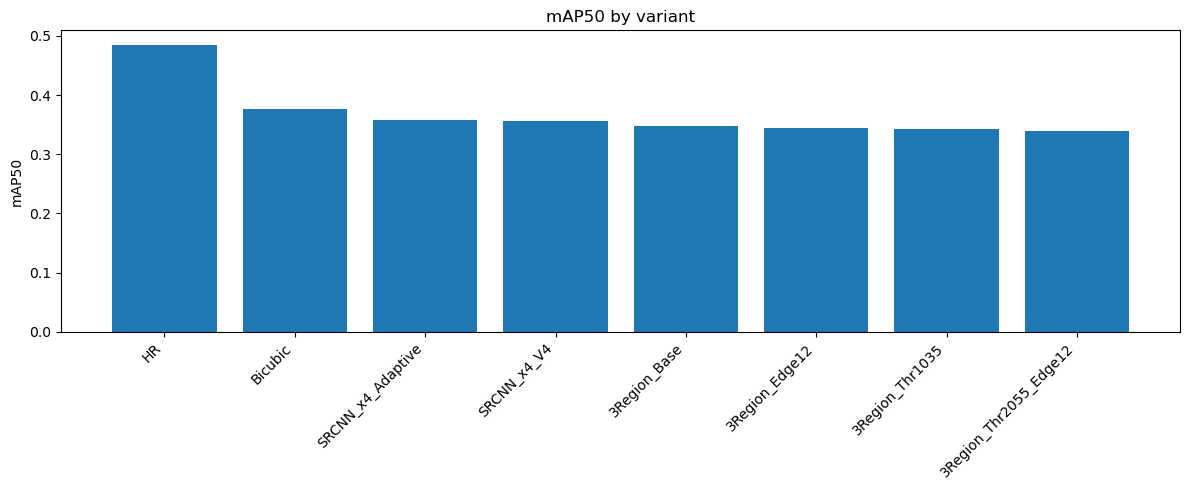

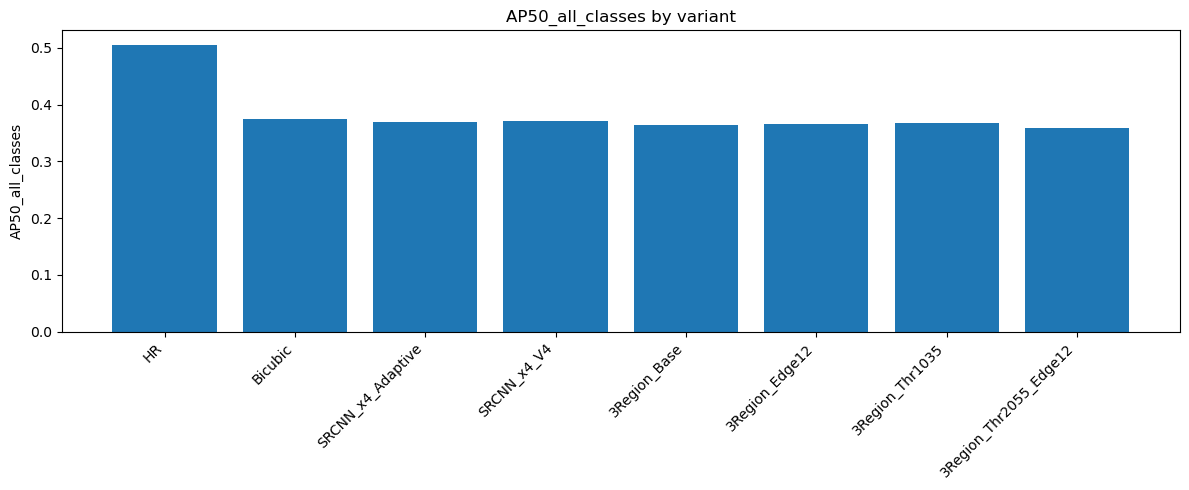

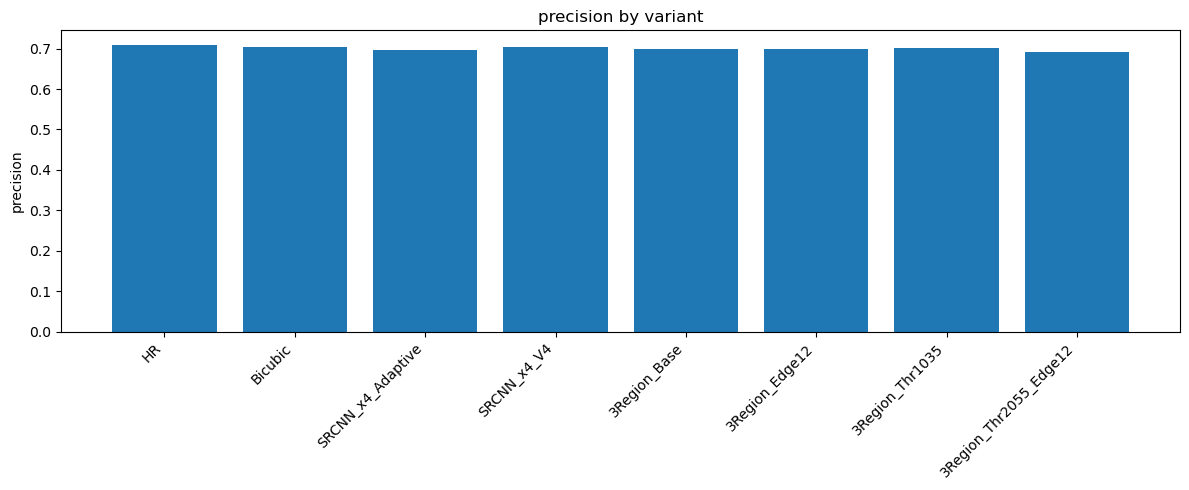

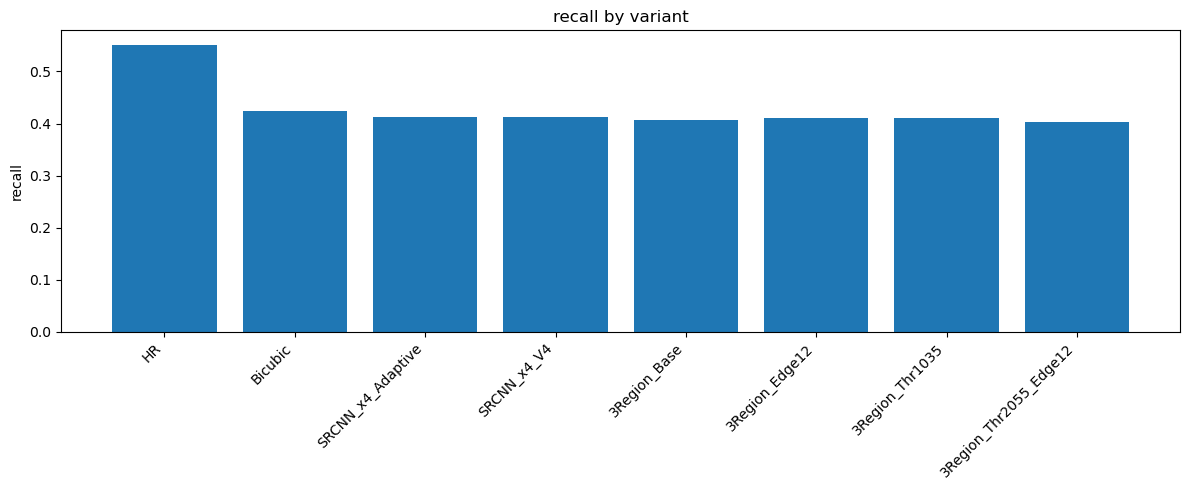

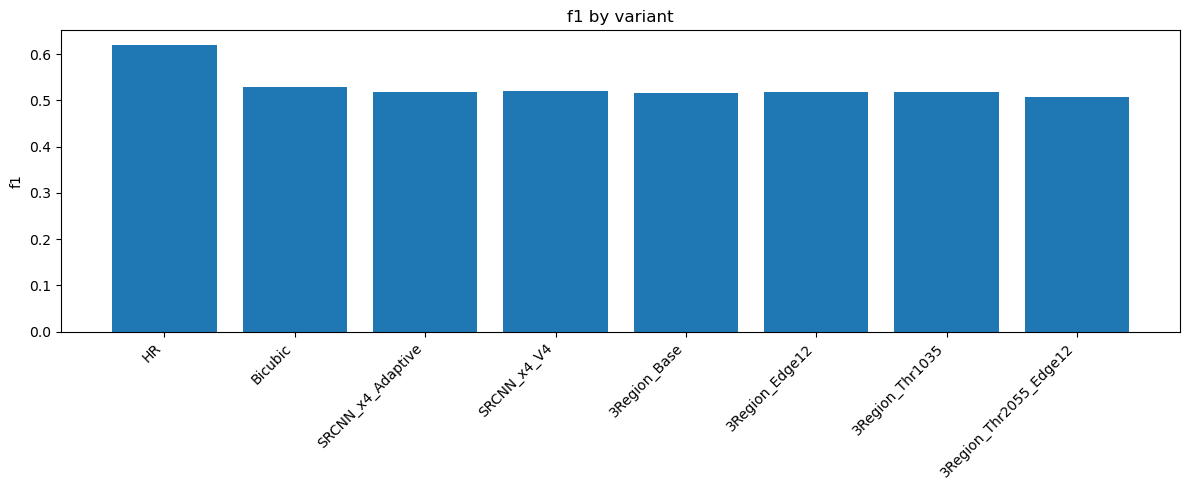

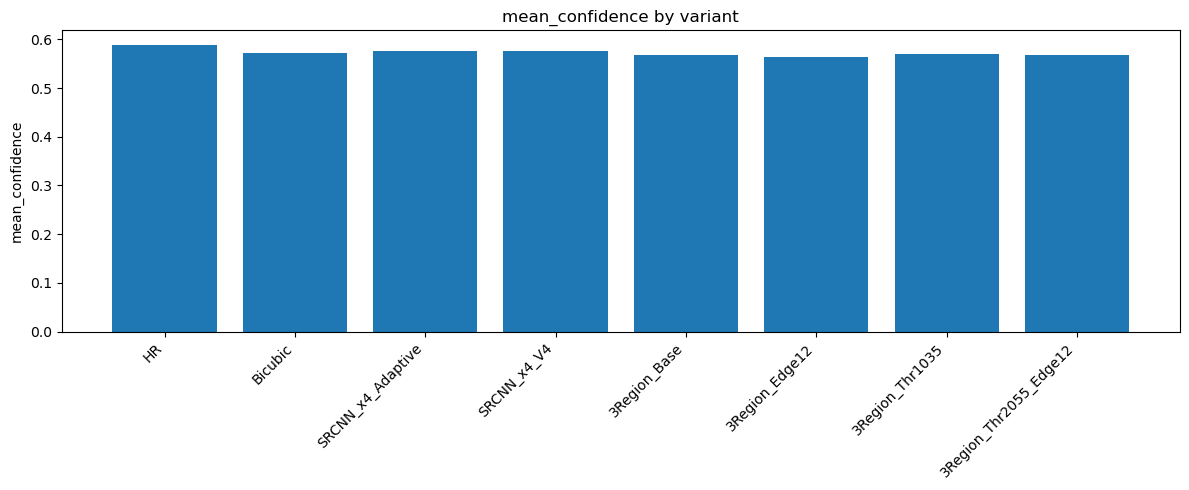

In [13]:

# -------------------------
# Plots
# -------------------------
plot_df = map_df.merge(
    summary_df[["variant", "AP50_all_classes", "precision", "recall", "f1", "mean_confidence"]],
    on="variant",
    how="left"
)

display(plot_df)

for metric in ["mAP50", "AP50_all_classes", "precision", "recall", "f1", "mean_confidence"]:
    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["variant"], plot_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} by variant")
    plt.tight_layout()
    plt.show()


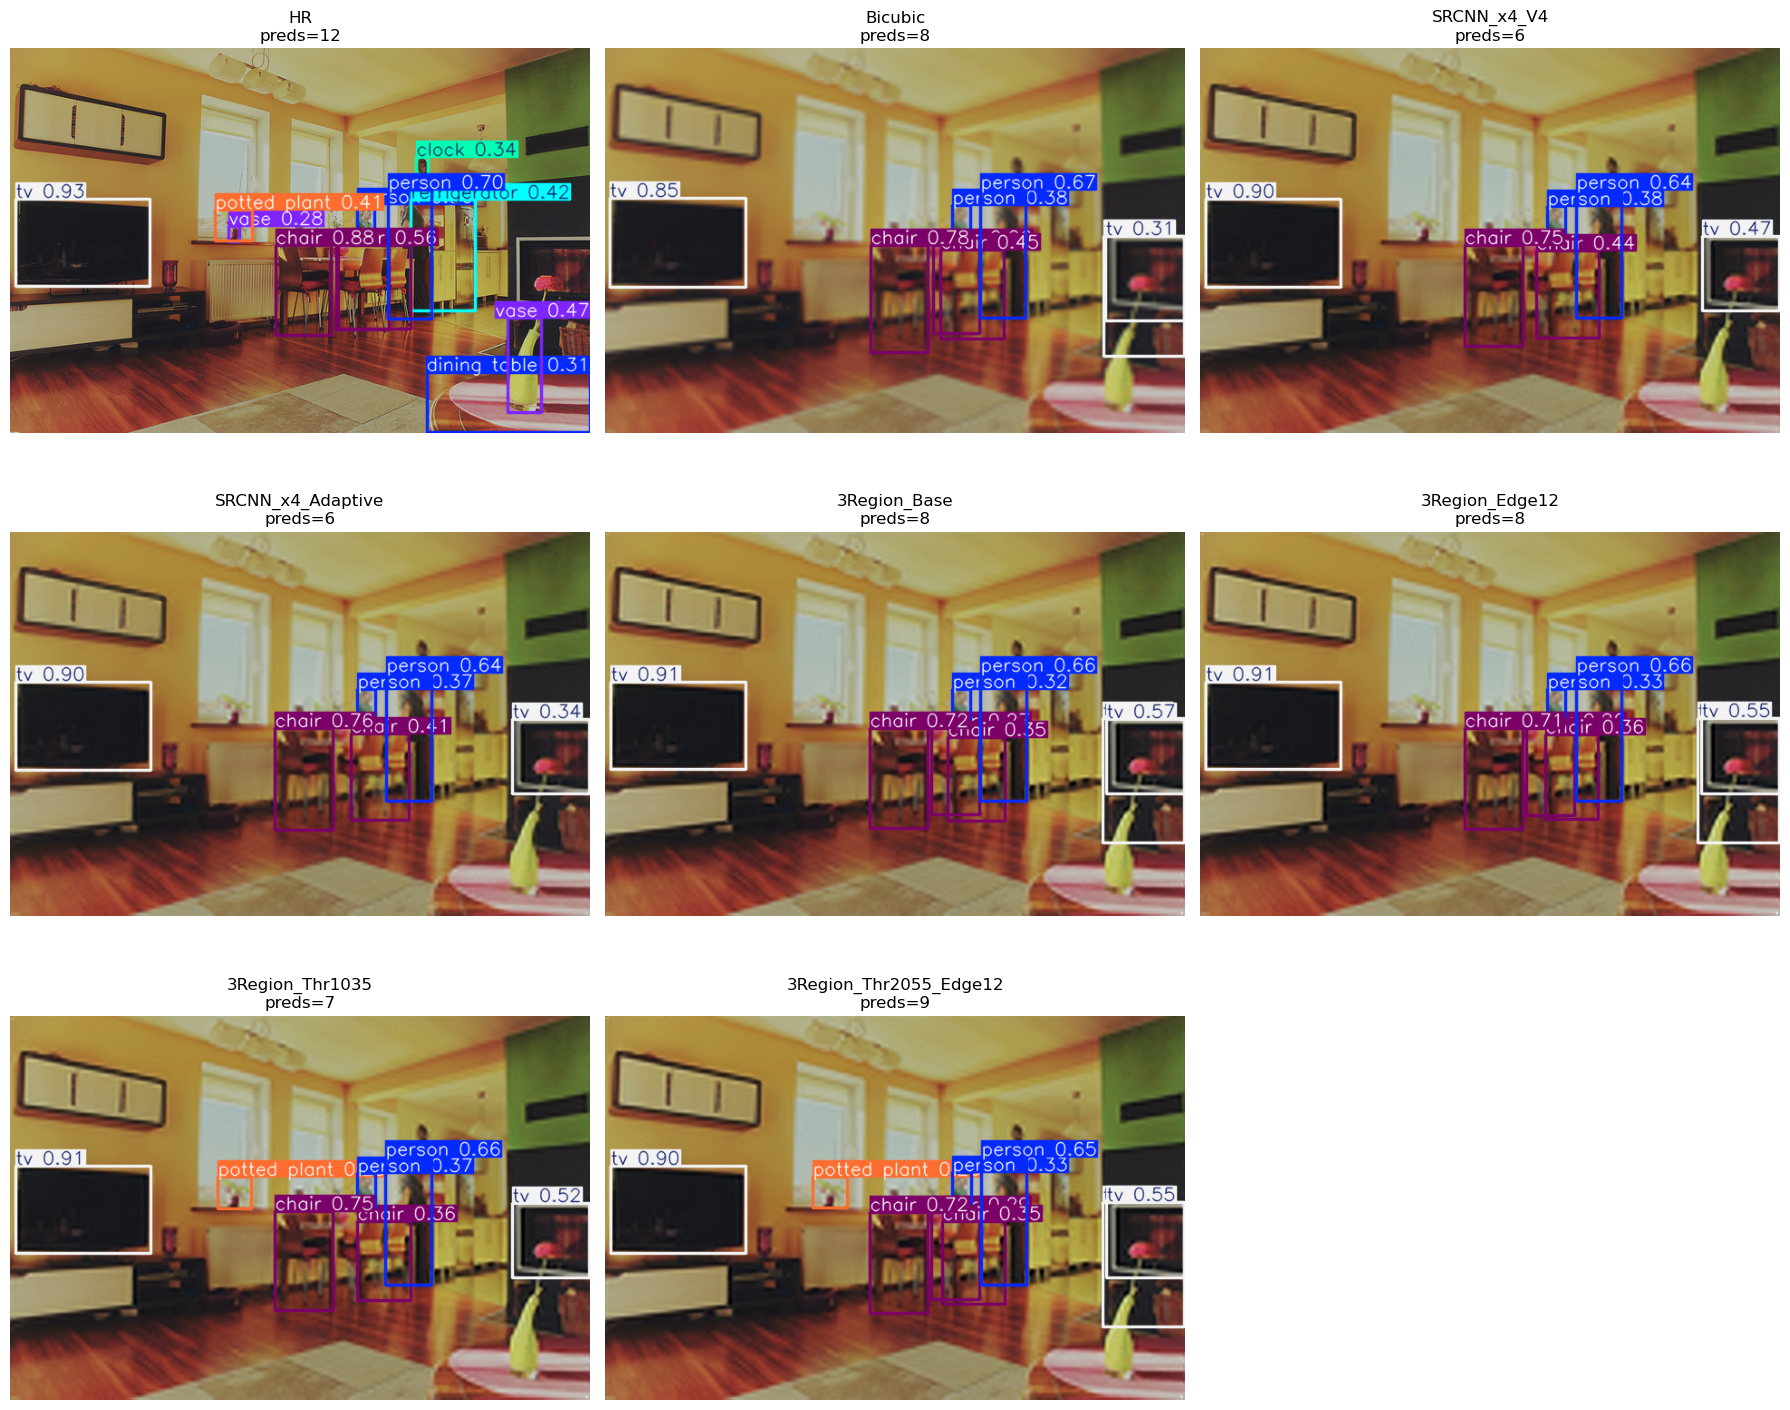

In [14]:

# -------------------------
# Visualize detections for one image
# -------------------------
def show_detection_grid(file_name: str, max_cols: int = 3):
    image_stem = Path(file_name).stem
    variants = ["HR", "Bicubic"] + list(models.keys())

    paths = []
    titles = []
    for variant in variants:
        p = OUTPUT_DET_DIR / f"{image_stem}__{variant}__det.png"
        if p.exists():
            paths.append(p)
            pred_count = len(pred_df[(pred_df["image"] == file_name) & (pred_df["variant"] == variant)])
            titles.append(f"{variant}\npreds={pred_count}")

    if not paths:
        raise ValueError(f"Nu există detecții salvate pentru {file_name}")

    cols = min(max_cols, len(paths))
    rows = math.ceil(len(paths) / cols)

    plt.figure(figsize=(6 * cols, 5 * rows))
    for i, (p, title) in enumerate(zip(paths, titles), start=1):
        img = Image.open(p).convert("RGB")
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(title)
    plt.tight_layout()
    plt.show()

if selected_files:
    show_detection_grid(selected_files[0], max_cols=3)


In [15]:

print("Summary AP50 all classes:")
display(summary_df)

print("mAP50 per class average:")
display(map_df)

print("Saved files:")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print(p)


Summary AP50 all classes:


,variant,num_gt,num_predictions,true_positives,false_positives,false_negatives,precision,recall,f1,AP50_all_classes,mean_confidence,max_confidence
0,HR,709,551,391,160,318,0.709619,0.551481,0.620635,0.505812,0.588961,0.963602
1,Bicubic,709,426,300,126,409,0.704225,0.423131,0.528634,0.375342,0.571724,0.951822
2,SRCNN_x4_V4,709,416,293,123,416,0.704327,0.413258,0.520889,0.371513,0.576918,0.951467
3,SRCNN_x4_Adaptive,709,420,292,128,417,0.695238,0.411848,0.517272,0.368699,0.574982,0.952905
6,3Region_Thr1035,709,415,291,124,418,0.701205,0.410437,0.517794,0.366939,0.570820,0.953441
5,3Region_Edge12,709,416,291,125,418,0.699519,0.410437,0.517333,0.365291,0.564378,0.953185
4,3Region_Base,709,413,289,124,420,0.699758,0.407616,0.515152,0.363915,0.566768,0.955432
7,3Region_Thr2055_Edge12,709,412,285,127,424,0.691748,0.401975,0.508475,0.359845,0.567429,0.952663


mAP50 per class average:


,variant,mAP50,mean_precision,mean_recall,classes_evaluated
5,HR,0.485223,0.649054,0.534794,72
4,Bicubic,0.376767,0.585743,0.409787,72
6,SRCNN_x4_Adaptive,0.358713,0.565430,0.383177,72
7,SRCNN_x4_V4,0.355615,0.537298,0.379181,72
0,3Region_Base,0.347100,0.556848,0.374102,72
1,3Region_Edge12,0.343926,0.562078,0.371819,72
2,3Region_Thr1035,0.342140,0.564001,0.370263,72
3,3Region_Thr2055_Edge12,0.338896,0.554020,0.374813,72


Saved files:
results_yolo_gt_compare\detection_map50_by_variant.csv
results_yolo_gt_compare\detection_metrics_ap50.csv
results_yolo_gt_compare\detection_per_class_ap50.csv
results_yolo_gt_compare\ground_truth_boxes.csv
results_yolo_gt_compare\prediction_matches_iou.csv
results_yolo_gt_compare\raw_yolo_predictions.csv



## Interpretare corectă

- `mean_confidence` NU înseamnă automat detecție corectă.
- `AP50_all_classes`, `precision`, `recall`, `mAP50` sunt relevante pentru că folosesc ground truth.
- Dacă un model are confidence mare, dar AP/precision mic, atunci YOLO e sigur pe predicții greșite.
- Pentru lucrare, folosește Set5/Set14 pentru PSNR/SSIM și COCO pentru impactul asupra detecției.
